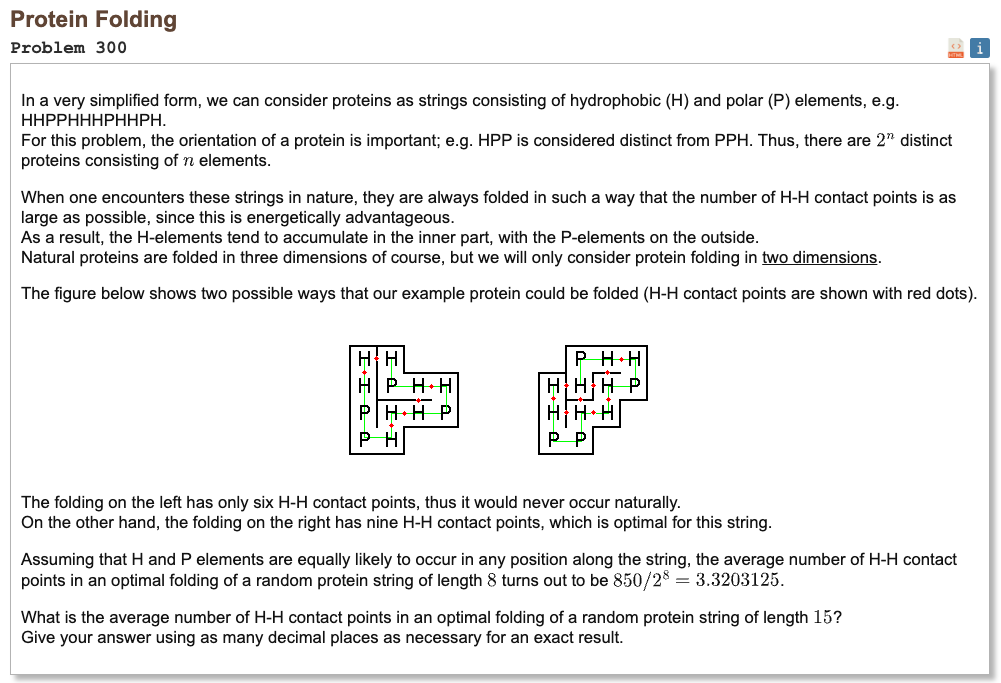

## Initial approach

* generate every self avoiding fold of length 15 on the square grid, while fixing the first step to remove rotations and reflections
* for each fold, record only the extra neighbor contacts that are not forced by the chain itself
* many different walks produce the same contact pattern, so keep only distinct contact patterns instead of every raw walk
* then loop over all 32768 H and P strings and ask which contact pattern gives that string the highest total contact count
* add those best scores over all strings and divide by 32768 at the end
* this matches the sample length 8 value from the problem statement, which is a good sanity check before doing length 15

In [1]:
def generate_contact_patterns(n):
    visited = {(0, 0), (1, 0)}
    path = [(0, 0), (1, 0)]
    patterns = set()
    directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]

    def dfs():
        if len(path) == n:
            if path[-1][1] < 0:
                return

            index = {p: i for i, p in enumerate(path)}
            contacts = []

            for i, (x, y) in enumerate(path):
                for dx, dy in ((1, 0), (0, 1)):
                    q = (x + dx, y + dy)
                    j = index.get(q)
                    if j is not None and abs(i - j) != 1:
                        contacts.append((1 << i) | (1 << j))

            if contacts:
                patterns.add(tuple(sorted(contacts)))
            return

        x, y = path[-1]
        for dx, dy in directions:
            q = (x + dx, y + dy)
            if q in visited:
                continue
            visited.add(q)
            path.append(q)
            dfs()
            path.pop()
            visited.remove(q)

    dfs()
    return list(patterns)

def solve(n):
    patterns = generate_contact_patterns(n)
    total_strings = 1 << n

    direct = [0] * total_strings
    best = [0] * total_strings

    for mask in range(total_strings):
        count = 0
        for i in range(n - 1):
            if ((mask >> i) & 3) == 3:
                count += 1
        direct[mask] = count
        best[mask] = count

    pair_ok = {}
    for i in range(n):
        for j in range(i + 2, n):
            pair = (1 << i) | (1 << j)
            pair_ok[pair] = [0] * total_strings
            for mask in range(total_strings):
                if (mask & pair) == pair:
                    pair_ok[pair][mask] = 1

    for contacts in patterns:
        extra = [0] * total_strings
        for pair in contacts:
            ok = pair_ok[pair]
            for mask in range(total_strings):
                extra[mask] += ok[mask]
        for mask in range(total_strings):
            score = direct[mask] + extra[mask]
            if score > best[mask]:
                best[mask] = score

    total = sum(best)
    result = total / total_strings
    return result

In [2]:
%%time
result = solve(15)
print("Result:", result)

Result: 8.0540771484375
CPU times: user 1min 14s, sys: 344 ms, total: 1min 15s
Wall time: 1min 15s
